# Assignment 07 - Clustering

This assignment will guide you through clustering algorithms: K-Means and DBSCAN. You'll learn how to preprocess data, find the optimal number of clusters, and understand when different algorithms work best.

### Import essential libraries
You can also import them while working on the assignment when needed.

In [14]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


---

## Part 1: The Clean-Up (Preprocessing)

**Context:** K-Means calculates the distance between points. If one column is "Age" (0-100) and another is "Income" (0-100,000), the Income column will dominate the distance calculation.

**Task:**
1. Load the `Mall_Customers.csv` file
2. Select the features: `Annual Income (k$)` and `Spending Score (1-100)`
3. **Crucial Step:** Apply `StandardScaler` to normalize these features
4. Plot the datapoints (Using scatter plot for example)

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df=df.drop(columns=["Age","Gender","CustomerID"])
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [5]:
scaler=StandardScaler()
df[["Annual Income (k$)","Spending Score (1-100)"]]=scaler.fit_transform(df[["Annual Income (k$)","Spending Score (1-100)"]])

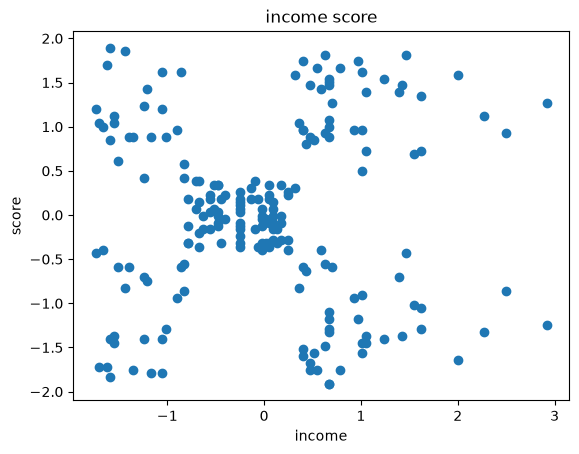

In [6]:
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"])
plt.xlabel("income")
plt.ylabel("score")
plt.title("income score")
plt.show()

---

## Part 2: The Hunt for K (K-Means)

**Context:** You don't know how many customer groups exist. Is it 3? 5? 10?

**Task:**
1. Run K-Means for $K=2$ to $K=10$
2. Calculate the WCSS (Within-Cluster Sum of Squares) for each
3. Plot the "Elbow Curve", Where does the elbow bend?
5. **Validate:** Calculate the Silhouette Score for your chosen $K$ to confirm it's a good split

Text(0.5, 1.0, 'elbow')

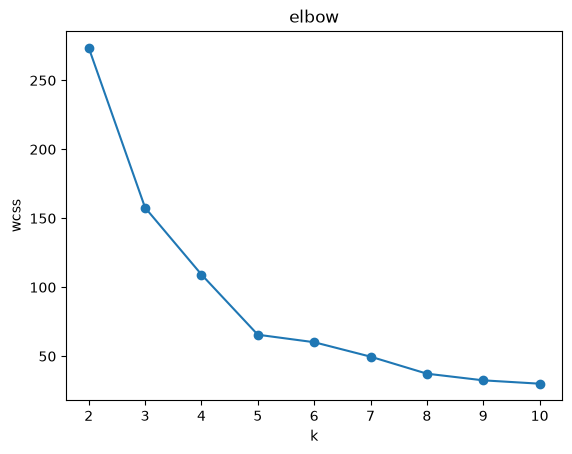

In [13]:
wcss=[]
k_range= range (2,11)
for k in k_range :
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df)
    wcss.append(model.inertia_)

plt.plot(k_range,wcss,marker="o")
plt.xlabel("k")
plt.ylabel("wcss")
plt.title("elbow")


elbow bend when x = 5

In [20]:
silhouette_scrores = []
k_range = range(2, 10)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df)
    pred = model.predict(df)
    score = silhouette_score(df, pred)
    silhouette_scrores.append(score)
    print(f"k = {k} --> silhouette_Score = {score:.4f}")

k = 2 --> silhouette_Score = 0.3973
k = 3 --> silhouette_Score = 0.4666
k = 4 --> silhouette_Score = 0.4943
k = 5 --> silhouette_Score = 0.5547
k = 6 --> silhouette_Score = 0.5138
k = 7 --> silhouette_Score = 0.5020
k = 8 --> silhouette_Score = 0.4550
k = 9 --> silhouette_Score = 0.4567


---

## Part 3: The Reveal (Visualization & Interpretation)

**Context:** The marketing team doesn't understand math. They need a chart.

**Task:**
1. Train the final K-Means model with your chosen $K$
2. Create a Scatter Plot:
   - X-axis: Annual Income
   - Y-axis: Spending Score
   - Color the points based on their Cluster Label
   - Mark the Centroids (the center of each group) with a big 'X'

In [22]:
model = KMeans(n_clusters=5,random_state=42)
model.fit(df)
df["claster"]=model.predict(df)

In [26]:
df0=df[df["claster"]==0]
df1=df[df["claster"]==1]
df2=df[df["claster"]==2]
df3=df[df["claster"]==3]
df4=df[df["claster"]==4]

In [ ]:
d

In [27]:
model.cluster_centers_[:, 0]
model.cluster_centers_[:, 1]

array([-0.02645617,  1.23950275,  1.13217788, -1.28443907, -1.13696536])

In [34]:
df

,Annual Income (k$),Spending Score (1-100),claster
0,-1.738999,-0.434801,4
1,-1.738999,1.195704,2
2,-1.700830,-1.715913,4
3,-1.700830,1.040418,2
4,-1.662660,-0.395980,4
...,...,...,...
195,2.268791,1.118061,1
196,2.497807,-0.861839,3
197,2.497807,0.923953,1
198,2.917671,-1.250054,3


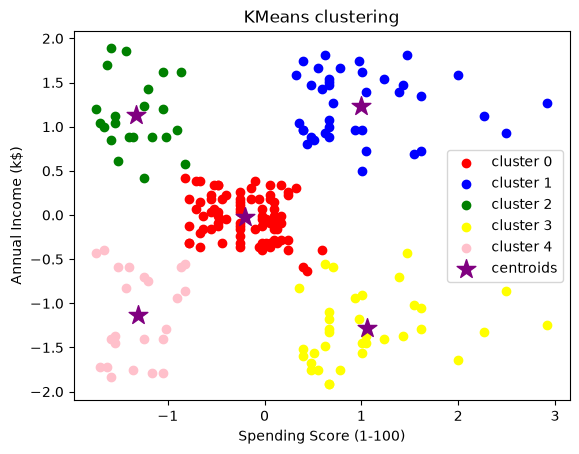

In [35]:
plt.scatter( df0['Annual Income (k$)'], df0['Spending Score (1-100)'],color='red', label='cluster 0')
plt.scatter( df1['Annual Income (k$)'], df1['Spending Score (1-100)'],color='blue', label='cluster 1')
plt.scatter( df2['Annual Income (k$)'],df2['Spending Score (1-100)'], color='green', label='cluster 2')
plt.scatter( df3['Annual Income (k$)'],df3['Spending Score (1-100)'], color='yellow', label='cluster 3')
plt.scatter( df4['Annual Income (k$)'],df4['Spending Score (1-100)'], color='pink', label='cluster 4')

plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], color='purple', marker='*', s=200, label="centroids")
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Annual Income (k$)')
plt.title("KMeans clustering")
plt.legend()
plt.show()

---

## Part 4: The "Glitch" (DBSCAN vs. K-Means)

**Context:** Your boss suspects the data might get messy in the future. She asks, "What if the customer groups aren't round blobs? What if they are shaped like crescents or rings?"

### Step 1: Generate Synthetic Data

**Task:** Generate synthetic moon-shaped data using the following code:

In [8]:
from sklearn.datasets import make_moons
X_moon, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

### Step 2: Fail Test - K-Means on Moon Data

**Task:** Run K-Means on the Moon data and plot it. Does it look right? (Spoiler: No, it cuts the moons in half)  
**Note:** We only need 2 centroids (Two Clusters)

- **Fit K-Means (K=2):** Train K-Means on `X_moon` with 2 clusters.  
- **Predict labels:** Use the fitted model to get cluster labels.  
- **Plot results:** Scatter plot `X_moon` and color by cluster labels. (*Optional:* Plot Cluster centroids positions)

*Outcomes Does it correctly split the two moons ?*

### Step 3: Success Test - DBSCAN on Moon Data

**Task:** Run DBSCAN on the Moon data. Tune `eps` and `min_samples` until you perfectly capture the two crescent shapes.

- **Fit DBSCAN:** Train DBSCAN on `X_moon` with different `eps` and `min_samples` values using `fit_predict()`.
- **Plot results:** Create scatter plots of `X_moon` colored by cluster labels for different parameter combinations.
- **Objective:** Find the parameter values that best separate the two moon shapes without incorrectly merging or splitting them.

### Step 4: Reflection (Optional)

**Question:** Why did DBSCAN win here? Write your answer below.

**Your Answer:**



In [9]:
"""

"""

'\n\n'